# Wavelet clusters — uniform subsample, log amplitudes, one normalisation

Copy of `3.3_wavelet_clusters.ipynb`, fed by `3.2_wavelet_subsample_uniform.ipynb`. The
original is left untouched, and so are its output folders.

**Pipeline:** `log(x + EPS)` (if `LOG`) → one standardisation (`NORM`) → PCA to `CUTOFF`
variance → k-means (`K`) → nearest centroid for every frame of every session. **The training
frames and the labelled frames go through the same function with the same statistics**,
which the original did not do: it z-scored the training frames by their biased subsample's
stats and the labelled frames by full-session stats, and ~10% of frames changed label
because of it.

**`NORM`**
- `'session'`: each session is z-scored by its **own full-session** mean and SD. This removes
  each session's overall amplitude level (camera distance, pixel scale, and also real vigour)
  by construction, as the original did.
- `'global'`: one mean and SD for everybody, from the pooled training set. This only puts the
  features on a common scale; **between-session level differences, rig included, stay in.**

The original's second and third z-scores (per-session on the subsample, then pooled, then
`global_mean`/`global_std` at labelling) were exact no-ops once sessions were already mean 0 /
SD 1, so there is one standardisation here.

**Bugs fixed from the original**
- The elbow plot fitted k-means on PCs 0–1 only; it now uses all retained PCs (k is still
  fixed by `K`; the elbow is only a diagnostic).
- The example t-SNE labelled frames with `(x - global_mean) / global_std`, skipping the
  session z-score, so its colours were not the saved states. It now uses `label_session`.
- The per-session plot measured distances to the centroids without PCA. It now uses
  `label_session`, and draws only `N_PLOT_SESSIONS` sessions instead of all of them.
- `sessions_to_exclude` held eids but was compared against `(mouse, eid)` tuples, so **nothing
  was ever excluded**. The list is kept as `EXCLUDE`; `APPLY_EXCLUDE = False` reproduces the
  original behaviour.
- The chained assignment `design_matrix[state_name][not_nan] = ...` is gone (it was not used).

**State numbering.** Clusters are renumbered by mean standardised power, so state 0 is the
stillest and state K−1 the most vigorous. The hand-written `fix_mapping` tables of the original
refer to its own cluster numbering and do not apply here.

In [1]:
"""SHARED DEFINITIONS -- identical in 3.2_..._uniform and 3.3_..._uniform."""
import os
import numpy as np
import pandas as pd

DATA = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

BANDS = ['0.5', '1.0', '2.0', '4.0', '8.0']       # the bands the clustering uses
FEATURES = {
    'paw':      [f'{p}_{a}{b}' for p in ('l_paw', 'r_paw') for a in 'xy' for b in BANDS],
    'left_paw': [f'l_paw_{a}{b}' for a in 'xy' for b in BANDS],
    'wheel':    [f'avg_wheel_vel{b}' for b in ('4.0', '8.0', '16.0', '32.0')],
}
WAVELETS = {       # VAR -> (folder, file prefix)
    'paw':      ('paw_wavelets/', 'paw_vel_wavelets_'),
    'left_paw': ('left_paw_wavelets/', 'paw_vel_wavelets_'),
    'wheel':    ('wheel_wavelets/', 'wheel_vel_wavelets_'),
}


def session_tags(var):
    """'<eid>_<mouse>' for every wavelet file of this VAR (top level only, as before)."""
    folder, prefix = WAVELETS[var]
    return sorted(f[len(prefix):] for f in os.listdir(DATA + folder) if f.startswith(prefix))


def load_session(var, tag):
    """-> (raw amplitudes of the frames with every feature finite, their Bin, the mask)."""
    folder, prefix = WAVELETS[var]
    df = pd.read_parquet(DATA + folder + prefix + tag, columns=FEATURES[var] + ['Bin'])
    X = df[FEATURES[var]].to_numpy(float)
    valid = np.isfinite(X).all(axis=1)
    return X[valid], df['Bin'].to_numpy()[valid], valid


In [2]:
"""IMPORTS AND KNOBS"""
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from kneed import KneeLocator

VAR    = 'paw'
LOG    = False           # log(x + EPS) before standardising; EPS comes from 3.2's files
NORM   = 'session'      # 'session' | 'global' -- see above
K      = 8            # the paper's paw states (paper_style.N_PAW_STATES)
CUTOFF = 0.95           # PCA variance kept
SEED   = 2024           # k-means seed, as in the original
N_PLOT_SESSIONS = 1

APPLY_EXCLUDE = False   # the original's list never took effect; True applies it
EXCLUDE = ['a8a8af78-16de-4841-ab07-fde4b5281a03', '8c33abef-3d3e-4d42-9f27-445e9def08f9',
           'ebe2efe3-e8a1-451a-8947-76ef42427cc9', '91bac580-76ed-41ab-ac07-89051f8d7f6e',
           '8a1cf4ef-06e3-4c72-9bc7-e1baa189841b', '64977c74-9c04-437a-9ea1-50386c4996db',
           '90e524a2-aa63-47ce-b5b8-1b1941a1223a', '30af8629-7b96-45b7-8778-374720ddbc5e',
           'f3eeb2d4-87ce-49ae-8a74-21665f6f1536', 'fcd49e34-f07b-441c-b2ac-cb8c462ec5ac']

SUB_DIR = DATA + f'{VAR}_subsampled_wavelets_uniform/'
STATES_DIR = DATA + f'{VAR}_states_uniform_{"log" if LOG else "raw"}_{NORM}z/'
os.makedirs(STATES_DIR, exist_ok=True)
print('states ->', STATES_DIR)

states -> /home/ines/repositories/representation_learning_variability/paper-individuality/data/paw_states_uniform_raw_sessionz/


In [3]:
"""LOAD THE SUBSAMPLES"""
tags = [t[:-4] for t in sorted(os.listdir(SUB_DIR)) if t.endswith('.npz')]
if APPLY_EXCLUDE:
    tags = [t for t in tags if t[:36] not in EXCLUDE]
subs = {t: np.load(SUB_DIR + t + '.npz') for t in tags}
assert all(list(z['features']) == FEATURES[VAR] for z in subs.values())
EPS = float(next(iter(subs.values()))['eps'])
assert all(float(z['eps']) == EPS for z in subs.values())
print(f'{len(tags)} sessions, EPS = {EPS}')


def amp(raw):
    """The amplitude scale the clustering works in."""
    return np.log(raw + EPS) if LOG else raw


def session_stats(raw):
    """Full-session mean and SD in the working scale (ddof=0, as scipy.stats.zscore)."""
    x = amp(raw)
    return x.mean(0), x.std(0)


# 'global': ONE mean/SD from the pooled training set (every session weighs the same)
_pool = np.vstack([amp(z['sub']) for z in subs.values()])
POOLED = (_pool.mean(0), _pool.std(0))


def stats_for(tag):
    if NORM == 'global':
        return POOLED
    z = subs[tag]
    return (z['mean_log'], z['sd_log']) if LOG else (z['mean_raw'], z['sd_raw'])


def standardise(raw, stats):
    mean, sd = stats
    return (amp(raw) - mean) / sd


X_train = np.vstack([standardise(subs[t]['sub'], stats_for(t)) for t in tags])
print('training set', X_train.shape)

332 sessions, EPS = 0.1


training set (664000, 20)


## PCA

14 PCs keep 95.5% of the variance


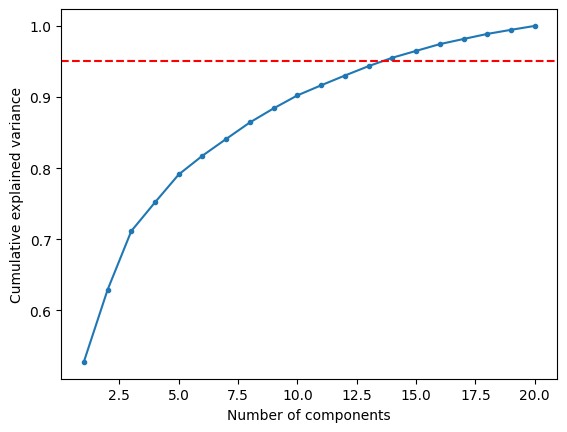

In [4]:
pca = PCA(n_components=len(FEATURES[VAR])).fit(X_train)
cumvar = np.cumsum(pca.explained_variance_ratio_)
N_PC = int(np.searchsorted(cumvar, CUTOFF) + 1)
if VAR == 'wheel':
    N_PC = len(FEATURES[VAR])
P_train = pca.transform(X_train)[:, :N_PC]
print(f'{N_PC} PCs keep {cumvar[N_PC - 1]:.1%} of the variance')

plt.plot(np.arange(1, len(cumvar) + 1), cumvar, 'o-', ms=3)
plt.axhline(CUTOFF, color='r', ls='--')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.show()

## Elbow (diagnostic only — `K` is set above)
Fixed: fitted on all retained PCs, not just the first two. A random 100,000 training frames
keep the 25 fits quick; the inertia curve is smooth enough that this does not move the knee.

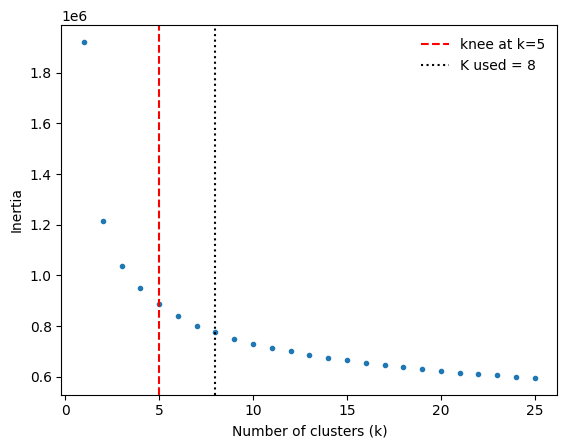

In [5]:
_rows = np.random.default_rng(0).choice(len(P_train), min(100_000, len(P_train)), replace=False)
Ks = range(1, 26)
inertia = [KMeans(n_clusters=k, random_state=42).fit(P_train[_rows]).inertia_ for k in Ks]
knee = KneeLocator(list(Ks), inertia, curve='convex', direction='decreasing').knee
plt.plot(list(Ks), inertia, 'o', ms=3)
plt.axvline(knee, color='r', ls='--', label=f'knee at k={knee}')
plt.axvline(K, color='k', ls=':', label=f'K used = {K}')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia'); plt.legend(frameon=False)
plt.show()

## k-means, renumbered stillest → most vigorous

In [6]:
km = KMeans(n_clusters=K, random_state=SEED).fit(P_train)
_power = np.array([X_train[km.labels_ == c].mean() for c in range(K)])
ORDER = np.argsort(_power)                 # new state s = old cluster ORDER[s]
CENTROIDS = km.cluster_centers_[ORDER]
train_states = np.argsort(ORDER)[km.labels_]
print('training occupancy by state:', np.round(np.bincount(train_states, minlength=K) / len(train_states), 3))

training occupancy by state: [0.376 0.258 0.117 0.107 0.05  0.045 0.038 0.008]


## Label every frame of every session

In [7]:
def label_session(tag):
    """Every valid frame of one session -> (states, centroid distances, Bin, valid mask, raw).

    The same standardise() the training frames went through. For NORM='session' the stats
    are recomputed from the full session and checked against the ones 3.2 saved."""
    raw, bins, valid = load_session(VAR, tag)
    if NORM == 'session':
        stats = session_stats(raw)
        assert np.allclose(stats[0], stats_for(tag)[0]) and np.allclose(stats[1], stats_for(tag)[1])
    else:
        stats = POOLED
    P = pca.transform(standardise(raw, stats))[:, :N_PC]
    D = cdist(P, CENTROIDS)
    return D.argmin(1), D, bins, valid, raw


occupancy = {}
for tag in tags:
    states, D, bins, _, _ = label_session(tag)
    session, mouse = tag[:36], tag[37:]
    # same file names and layout as the original, so 4.0_hmm_fit can point at STATES_DIR
    np.save(STATES_DIR + f'most_likely_states_{K}_{mouse}{session}', np.array([states, bins]))
    np.save(STATES_DIR + f'centroid_distances_{K}_{mouse}{session}', D)
    occupancy[tag] = np.bincount(states, minlength=K) / len(states)
occupancy = pd.DataFrame(occupancy, index=[f'state{s}' for s in range(K)]).T
print(f'labelled {len(occupancy)} sessions -> {STATES_DIR}')
occupancy.describe().round(3)

labelled 332 sessions -> /home/ines/repositories/representation_learning_variability/paper-individuality/data/paw_states_uniform_raw_sessionz/


,state0,state1,state2,state3,state4,state5,state6,state7
count,332.000,332.000,332.000,332.000,332.000,332.000,332.000,332.000
mean,0.377,0.258,0.117,0.107,0.050,0.044,0.038,0.008
std,0.061,0.052,0.020,0.040,0.015,0.012,0.008,0.004
min,0.240,0.103,0.060,0.020,0.012,0.007,0.011,0.000
25%,0.334,0.222,0.105,0.078,0.041,0.037,0.033,0.005
50%,0.369,0.258,0.118,0.104,0.051,0.044,0.038,0.008
75%,0.413,0.290,0.131,0.135,0.060,0.052,0.043,0.011
max,0.587,0.427,0.166,0.215,0.089,0.075,0.058,0.023


## What the states are

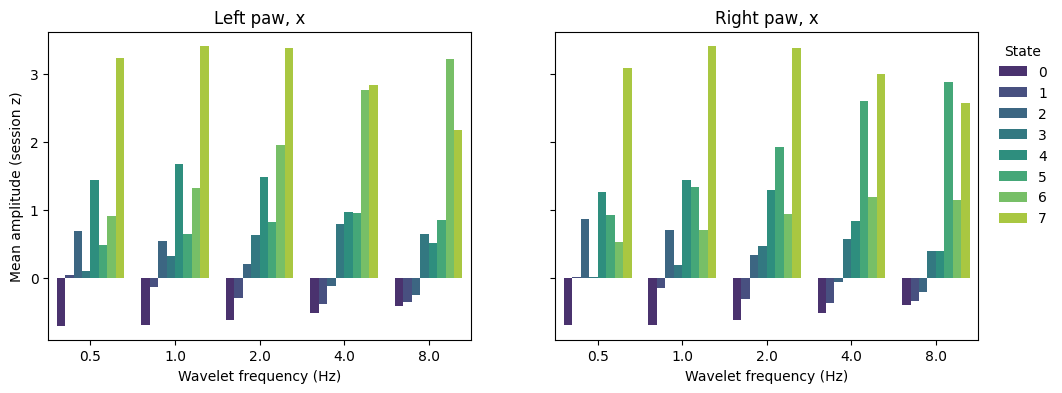

In [8]:
prof = pd.DataFrame(X_train, columns=FEATURES[VAR]).assign(state=train_states)
prof = prof.melt(id_vars='state')
palette = sns.color_palette('viridis', K)

if VAR in ('paw', 'left_paw'):
    sides = [('l_paw', 'Left paw'), ('r_paw', 'Right paw')] if VAR == 'paw' else [('l_paw', 'Left paw')]
    fig, axes = plt.subplots(1, len(sides), figsize=(6 * len(sides), 4), sharey=True, squeeze=False)
    for ax, (p, name) in zip(axes[0], sides):
        cols = [f'{p}_x{b}' for b in BANDS]
        sns.barplot(data=prof[prof['variable'].isin(cols)], x='variable', y='value', hue='state',
                    palette=palette, ax=ax, errorbar=None)
        ax.set_xticks(range(len(BANDS)), BANDS)
        ax.set_xlabel('Wavelet frequency (Hz)'); ax.set_title(f'{name}, x')
        ax.legend_.remove()
    axes[0][0].set_ylabel(f'Mean {"log " if LOG else ""}amplitude ({NORM} z)')
    axes[0][-1].legend(title='State', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
    plt.show()

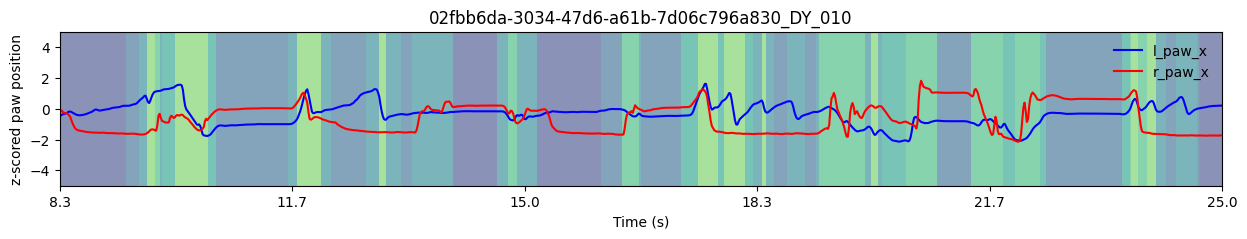

In [9]:
"""Example sessions: states under the paw traces. Fixed: uses label_session."""
from matplotlib.colors import ListedColormap
cmap = ListedColormap(palette)
for tag in tags[:N_PLOT_SESSIONS]:
    states, _, bins, valid, _ = label_session(tag)
    folder, prefix = WAVELETS[VAR]
    dm = pd.read_parquet(DATA + folder + prefix + tag)[valid].reset_index(drop=True)
    init, inter, fr = 500, 1000, 60
    fig, ax = plt.subplots(figsize=(15, 2))
    ax.imshow(states[None, :], extent=(0, len(states), -10, 10), aspect='auto', alpha=0.6,
              cmap=cmap, vmin=-0.5, vmax=K - 0.5, interpolation='nearest')
    for c, col in [('l_paw_x', 'blue'), ('r_paw_x', 'red')]:
        if c in dm:
            v = dm[c].to_numpy()
            ax.plot((v - np.nanmean(v)) / np.nanstd(v), color=col, label=c)
    ax.set_xlim(init, init + inter); ax.set_ylim(-5, 5)
    ax.set_xticks(np.arange(init, init + inter + 1, inter / 5),
                  np.round(np.arange(init, init + inter + 1, inter / 5) / fr, 1))
    ax.set_xlabel('Time (s)'); ax.set_ylabel('z-scored paw position')
    ax.set_title(tag); ax.legend(frameon=False, loc='upper right')
    plt.show()

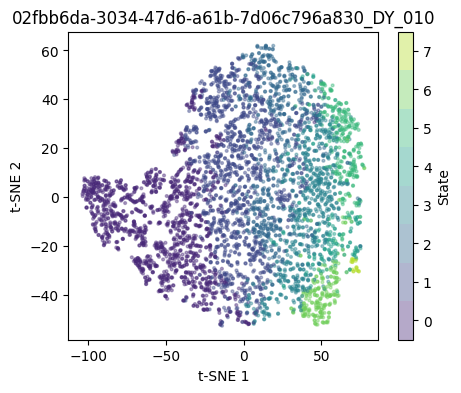

In [10]:
"""t-SNE of one example session, coloured by the SAVED states. Fixed: uses label_session."""
from sklearn.manifold import TSNE
tag = tags[0]
states, _, _, _, raw = label_session(tag)
stats = session_stats(raw) if NORM == 'session' else POOLED
P = pca.transform(standardise(raw, stats))[:, :N_PC]
pick = np.random.default_rng(0).choice(len(P), min(5000, len(P)), replace=False)
emb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(P[pick])
plt.figure(figsize=(5, 4))
sc = plt.scatter(*emb.T, c=states[pick], cmap=cmap, vmin=-0.5, vmax=K - 0.5, s=4, alpha=0.4)
plt.colorbar(sc, label='State', ticks=range(K))
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.title(tag)
plt.show()